# Continuous Control

---

In this notebook, you will learn how to use the Unity ML-Agents environment for the second project of the [Deep Reinforcement Learning Nanodegree](https://www.udacity.com/course/deep-reinforcement-learning-nanodegree--nd893) program.

### 1. Start the Environment

We begin by importing the necessary packages.  If the code cell below returns an error, please revisit the project instructions to double-check that you have installed [Unity ML-Agents](https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Installation.md) and [NumPy](http://www.numpy.org/).

In [1]:
import torch # used to save the weights file
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from unityagents import UnityEnvironment

from ddqnAgent import Agent, TD3Agent

Next, we will start the environment!  **_Before running the code cell below_**, change the `file_name` parameter to match the location of the Unity environment that you downloaded.

- **Mac**: `"path/to/Reacher.app"`
- **Windows** (x86): `"path/to/Reacher_Windows_x86/Reacher.exe"`
- **Windows** (x86_64): `"path/to/Reacher_Windows_x86_64/Reacher.exe"`
- **Linux** (x86): `"path/to/Reacher_Linux/Reacher.x86"`
- **Linux** (x86_64): `"path/to/Reacher_Linux/Reacher.x86_64"`
- **Linux** (x86, headless): `"path/to/Reacher_Linux_NoVis/Reacher.x86"`
- **Linux** (x86_64, headless): `"path/to/Reacher_Linux_NoVis/Reacher.x86_64"`

For instance, if you are using a Mac, then you downloaded `Reacher.app`.  If this file is in the same folder as the notebook, then the line below should appear as follows:
```
env = UnityEnvironment(file_name="Reacher.app")
```

In [2]:
env = UnityEnvironment(file_name='Reacher_Linux_NoVis_Single/Reacher.x86_64')

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_size -> 5.0
		goal_speed -> 1.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [3]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

In this environment, a double-jointed arm can move to target locations. A reward of `+0.1` is provided for each step that the agent's hand is in the goal location. Thus, the goal of your agent is to maintain its position at the target location for as many time steps as possible.

The observation space consists of `33` variables corresponding to position, rotation, velocity, and angular velocities of the arm.  Each action is a vector with four numbers, corresponding to torque applicable to two joints.  Every entry in the action vector must be a number between `-1` and `1`.

Run the code cell below to print some information about the environment.

In [4]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 1
Size of each action: 4
There are 1 agents. Each observes a state with length: 33
The state for the first agent looks like: [ 0.00000000e+00 -4.00000000e+00  0.00000000e+00  1.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.00000000e+01  0.00000000e+00
  1.00000000e+00 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.75471878e+00 -1.00000000e+00
  5.55726671e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
 -1.68164849e-01]


### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agent and receive feedback from the environment.

Once this cell is executed, you will watch the agent's performance, if it selects an action at random with each time step.  A window should pop up that allows you to observe the agent, as it moves through the environment.  

Of course, as part of the project, you'll have to change the code so that the agent is able to use its experience to gradually choose better actions when interacting with the environment!

In [5]:
'''
env_info = env.reset(train_mode=False)[brain_name]     # reset the environment    
states = env_info.vector_observations                  # get the current state (for each agent)
scores = np.zeros(num_agents)                          # initialize the score (for each agent)
while True:
    actions = np.random.randn(num_agents, action_size) # select an action (for each agent)
    actions = np.clip(actions, -1, 1)                  # all actions between -1 and 1
    env_info = env.step(actions)[brain_name]           # send all actions to tne environment
    next_states = env_info.vector_observations         # get next state (for each agent)
    rewards = env_info.rewards                         # get reward (for each agent)
    dones = env_info.local_done                        # see if episode finished
    scores += env_info.rewards                         # update the score (for each agent)
    states = next_states                               # roll over states to next time step
    if np.any(dones):                                  # exit loop if episode finished
        break
print('Total score (averaged over agents) this episode: {}'.format(np.mean(scores)))
'''
pass

When finished, you can close the environment.

In [6]:
#env.close()

### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```

In [7]:
def runDDPGAgent(agent, numEpisodes, maxSteps, epsStart, epsEnd, epsDecay, shouldTrain=True):
    """
    Run the Deep Q-Network agent
    ============================
    numEpisodes: number of episodes to run
    maxSteps: maximum number of timesteps to take per episode
    epsStart: starting value for epsilon
    epsEnd: minimum value for epsilon
    epsDecay: epsilon decay rate
    """
    
    # Initialize score containers
    scoreList = []
    last100Scores = deque(maxlen=100)
    
    # Initialize epsilon learning rate
    epsilon = epsStart
    
    for episodeNum in range(1, numEpisodes + 1):
        env_info = env.reset(train_mode=shouldTrain)[brain_name]
        state = env_info.vector_observations[0]
        score = 0
        
        for stepNum in range(maxSteps):
            action = agent.act(state, epsilon)
            env_info = env.step(action)[brain_name]
            nextState = env_info.vector_observations[0]
            reward = env_info.rewards[0]
            done = env_info.local_done[0]
            if shouldTrain:
                agent.step(state, action, reward, nextState, done)
            score += reward
            state = nextState
            
            
            if done:
                break
        scoreList.append(score)
        last100Scores.append(score)
            
        epsilon = max(epsEnd, epsilon*epsDecay)
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(episodeNum, np.mean(last100Scores)), end="")
        if episodeNum % 100 == 0:
            print('\rEpisode {}\tAverage Score: {:.2f}'.format(episodeNum, np.mean(last100Scores)))
        if np.mean(last100Scores)>=30.0:
            print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(episodeNum-100, np.mean(last100Scores)))
            torch.save(agent.QNet_Actor_Local.state_dict(), 'checkpoint.pth')
            break
    return scoreList

In [13]:
def runTD3Agent(agent, numEpisodes, maxSteps, epsStart, epsEnd, epsDecay, shouldTrain=True):
    """
    Run the Deep Q-Network agent
    ============================
    numEpisodes: number of episodes to run
    maxSteps: maximum number of timesteps to take per episode
    epsStart: starting value for epsilon
    epsEnd: minimum value for epsilon
    epsDecay: epsilon decay rate
    """
    
    # Initialize score containers
    scoreList = []
    last100Scores = deque(maxlen=100)
    
    # Initialize epsilon learning rate
    epsilon = epsStart
    
    for episodeNum in range(1, numEpisodes + 1):
        env_info = env.reset(train_mode=shouldTrain)[brain_name]
        state = env_info.vector_observations[0]
        score = 0
        
        for stepNum in range(maxSteps):
            action = agent.act(state, epsilon)
            env_info = env.step(action)[brain_name]
            nextState = env_info.vector_observations[0]
            reward = env_info.rewards[0]
            done = env_info.local_done[0]
            if shouldTrain:
                agent.step(state, action, reward, nextState, done)
            score += reward
            state = nextState
            
            
            if done:
                break
        scoreList.append(score)
        last100Scores.append(score)
            
        epsilon = max(epsEnd, epsilon*epsDecay)
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(episodeNum, np.mean(last100Scores)), end="")
        if episodeNum % 100 == 0:
            print('\rEpisode {}\tAverage Score: {:.2f}'.format(episodeNum, np.mean(last100Scores)))
        
        if shouldTrain:
            if np.mean(last100Scores)>=30.0:
                print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(episodeNum-100, np.mean(last100Scores)))
                torch.save(agent.QNet_Actor_Local.state_dict(), 'checkpoint.pth')
                break
    return scoreList, last100Scores

In [9]:
def plotScores(scoresIn):
    # plot the scores
    fig = plt.figure()
    ax = fig.add_subplot(111)
    plt.plot(np.arange(len(scoresIn)), scoresIn)
    plt.ylabel('Score')
    plt.xlabel('Episode #')
    plt.show()

In [10]:
def saveScoresToFile(fileName, scores):
    outFile = open(fileName, 'w')
    for item in scores:
        outFile.write(str(item) + "\n")
    outFile.close()

Episode 100	Average Score: 1.23
Episode 200	Average Score: 1.53
Episode 300	Average Score: 1.23
Episode 400	Average Score: 1.77
Episode 500	Average Score: 3.96
Episode 600	Average Score: 6.31
Episode 700	Average Score: 11.09
Episode 800	Average Score: 19.64
Episode 898	Average Score: 30.12
Environment solved in 798 episodes!	Average Score: 30.12


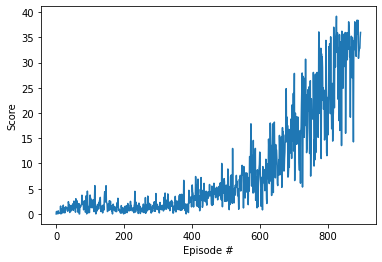

In [11]:
# From the project description, we know the action bounds are -1 to 1
actionBounds = [-1,1]
numEpisodes = 20000
numSteps = 1000
totalSteps = numEpisodes * numSteps
agent = TD3Agent(actionBounds, state_size, action_size, 343, totalSteps, usePER=False)
scores, avg100Scores = runTD3Agent(agent, numEpisodes, numSteps, 1.0, 0.01, 0.999)
saveScoresToFile("outputScores.txt", scores)
saveScoresToFile("outputScoresAvg.txt", avg100Scores)
plotScores(scores)

Episode 100	Average Score: 33.14
Episode 200	Average Score: 33.56
Episode 300	Average Score: 33.09
Episode 400	Average Score: 33.18
Episode 500	Average Score: 33.37
Episode 600	Average Score: 33.72
Episode 700	Average Score: 32.14
Episode 800	Average Score: 32.77
Episode 900	Average Score: 33.34
Episode 1000	Average Score: 33.13


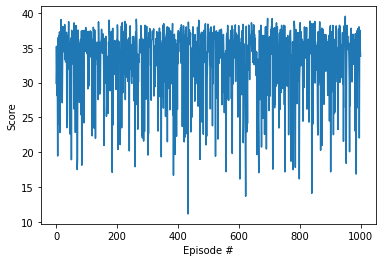

In [14]:
# Run a trained agent
actionBounds = [-1, 1]
numEpisodes = 1000
numSteps = 1000
totalSteps = numEpisodes*numSteps
agent = TD3Agent(actionBounds, state_size, action_size, 343, totalSteps, fileName="checkpoint.pth")
scores, avg100Scores = runTD3Agent(agent, 1000, 1000, 1.0, 0.01, 0.999, shouldTrain=False)
saveScoresToFile("outputScoresInference.txt", scores)
saveScoresToFile("outputScoresAvgInference.txt", avg100Scores)
plotScores(scores)

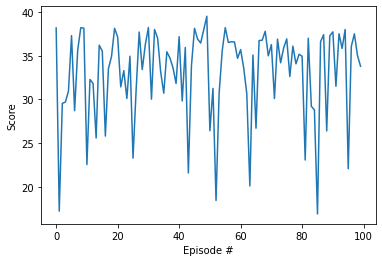

In [15]:
plotScores(avg100Scores)